In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

In [3]:
url = 'https://raw.githubusercontent.com/omarmendoza564/datos/main/datos/data_nybirths.dat'
births = pd.read_csv(url, header=None, names=['Births'])
births

,Births
0,26.663
1,23.598
2,26.931
3,24.740
4,25.806
...,...
163,30.000
164,29.261
165,29.012
166,26.992


In [5]:
#COnvertir el DF en una serie de tiempo
births.index = pd.date_range('1946-01', periods=len(births), freq='ME')
births

,Births
1946-01-31,26.663
1946-02-28,23.598
1946-03-31,26.931
1946-04-30,24.740
1946-05-31,25.806
...,...
1959-08-31,30.000
1959-09-30,29.261
1959-10-31,29.012
1959-11-30,26.992


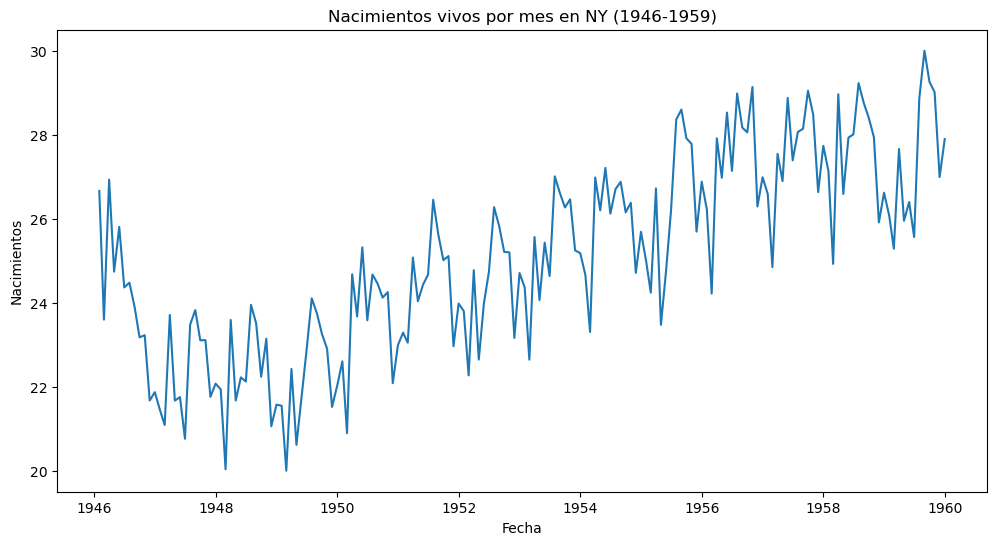

In [9]:
#Graficar las serie de tiempo
plt.figure(figsize = (12,6))
plt.plot(births.index, births.Births)
plt.xlabel('Fecha')
plt.ylabel('Nacimientos')
plt.title('Nacimientos vivos por mes en NY (1946-1959)')
plt.show()

In [10]:
#Boxpllot de nacimientos por mes
births['Month'] = births.index.month
births

,Births,Month
1946-01-31,26.663,1
1946-02-28,23.598,2
1946-03-31,26.931,3
1946-04-30,24.740,4
1946-05-31,25.806,5
...,...,...
1959-08-31,30.000,8
1959-09-30,29.261,9
1959-10-31,29.012,10
1959-11-30,26.992,11


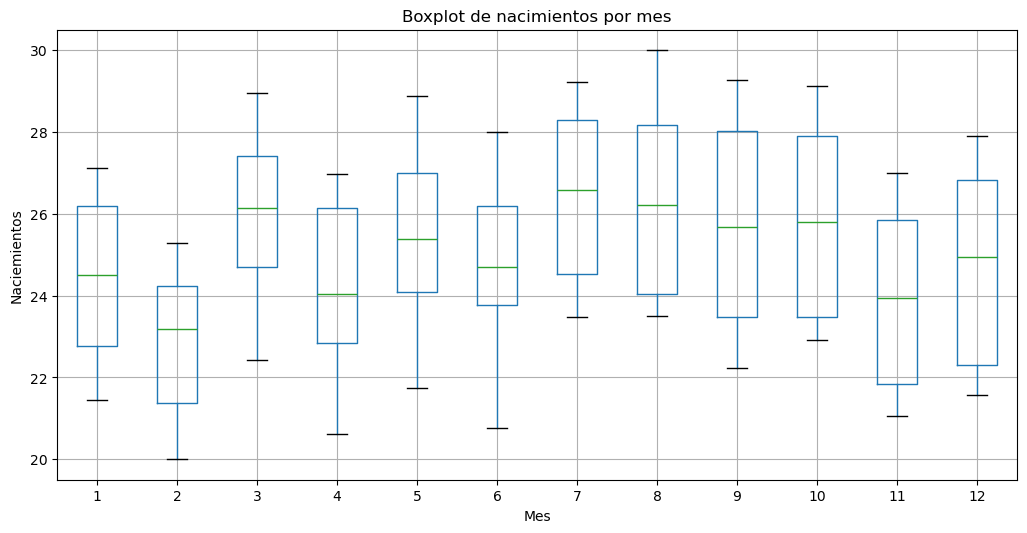

In [11]:
births.boxplot(column='Births', by = 'Month', figsize = (12,6))
plt.xlabel('Mes')
plt.ylabel('Naciemientos')
plt.title('Boxplot de nacimientos por mes')
plt.suptitle('')
plt.show()

<Figure size 1200x800 with 0 Axes>

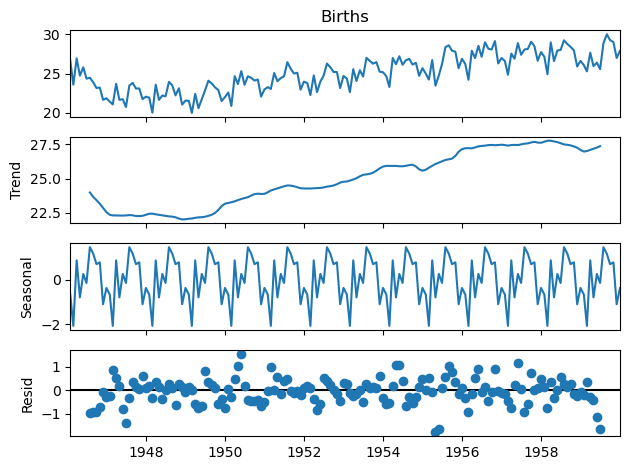

In [13]:
# Ver los componentes de la serie de tiempo (descomposicion)
#Tendencia, estacionalidad, residual
plt.figure(figsize = (12,8))
descomposition = seasonal_decompose(births.Births, model='additive', period=12)
descomposition.plot()
plt.show()

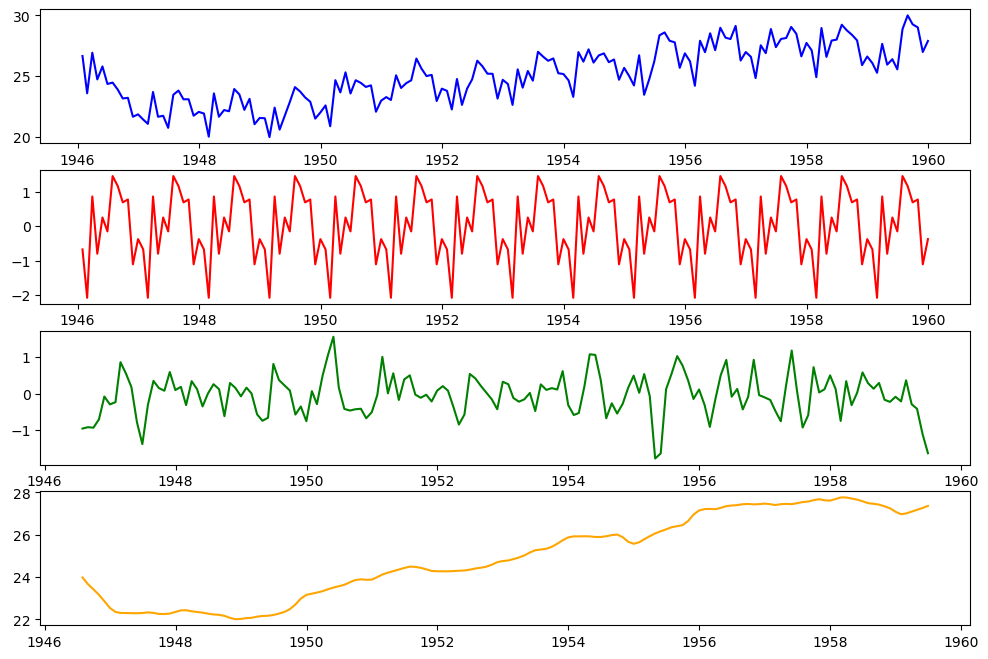

In [17]:
plt.figure(figsize = (12, 8))
plt.subplot(411)
plt.plot(descomposition.observed, label='Original', color = 'blue')

plt.subplot(412)
plt.plot(descomposition.seasonal, label='Estacional', color = 'red')

plt.subplot(413)
plt.plot(descomposition.resid, label='Residual', color = 'green')

plt.subplot(414)
plt.plot(descomposition.trend, label='Tendencia', color = 'orange')